# Analysis

### 1. Import thư viện cần thiết và load data

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

true_target = pd.read_csv("../data/preprocessed/data_test.csv")["throughput_down_mbps"]
pred_baseline = pd.read_csv("../data/prediction-baseline/prediction_baseline.csv")
pred_linear_regression = pd.read_csv("../data/prediction-linear-regression/prediction_linear_regression.csv")

pred_linear_regression = pred_linear_regression.to_numpy().flatten()

model = joblib.load("../models/linear_regression_model.joblib")

### 2. Tạo bảng so sánh giữa hai mô hình Mean và Linear Regression

In [106]:
models_performance = pd.DataFrame({
    'Model': ['Baseline (Mean)', 'Linear Regression'],
    'MAE': [mean_absolute_error(true_target, pred_baseline), mean_absolute_error(true_target, pred_linear_regression)],
    'RMSE': [root_mean_squared_error(true_target, pred_baseline), root_mean_squared_error(true_target, pred_linear_regression)],
    'R^2': [r2_score(true_target, pred_baseline), r2_score(true_target, pred_linear_regression)]
})

display(models_performance)

,Model,MAE,RMSE,R^2
0,Baseline (Mean),40.676235,42.340932,-0.003444
1,Linear Regression,7.203437,10.900410,0.933494


#### Ý nghĩa
- Mean Absolute Error (MAE): Trên trung bình, dự đoán của mô hình Linear Regression lệch khỏi giá trị đúng ~7.2 Mbps, rất gần so với mức lệch ~40.68 Mbps của mô hình Mean.
- Root Mean Squared Error (RMSE): Mô hình Linear Regression mắc ít lỗi lớn hơn mô hình Mean.
- Coefficient of determination (R^2): Mô hình Linear Regression phản ánh tốt sự biến thiên của thông lượng, trong khi mô hình Mean hầu như không phản ánh được điều này.

### 3. Bảng Coefficients của các biến đầu vào trong mô hình Linear Regression

Mô hình có y-intercept: -31.504708394830992


,Feature,Coefficient
0,distance_m,-0.021684
1,signal_mean_pct,1.093367
2,rx_link_rate_mean,0.040383
3,rtt_mean_ms,-0.005455
4,jitter_ms,-0.001275
5,packet_loss_pct,-0.105101


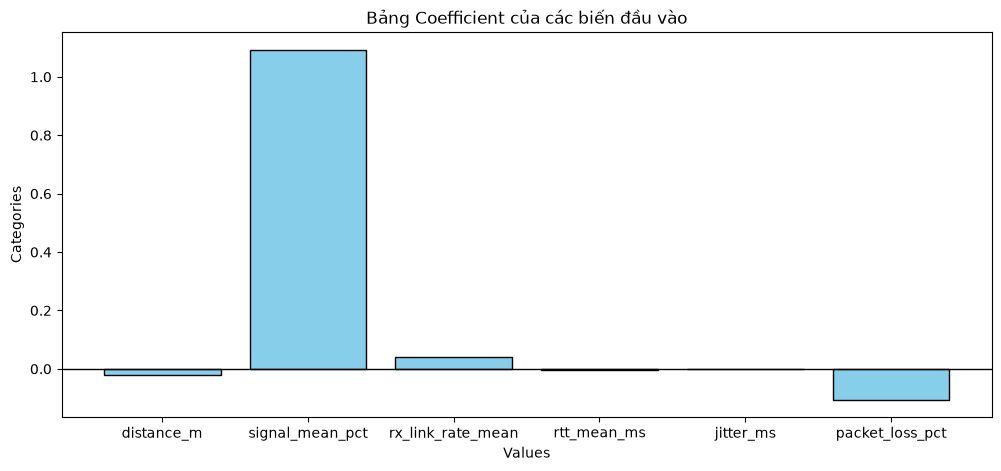

In [107]:
y_intercept = model.intercept_
coeff_table = pd.DataFrame({
    'Feature': model.feature_names_in_,
    'Coefficient': model.coef_
})

print("Mô hình có y-intercept:", y_intercept)
display(coeff_table)

plt.figure(figsize=(12, 5))
plt.bar(coeff_table['Feature'], coeff_table['Coefficient'], color='skyblue', edgecolor='black')
plt.axhline(y=0, color='black', linewidth=1)
plt.title('Bảng Coefficient của các biến đầu vào')
plt.xlabel('Values')
plt.ylabel('Categories')

plt.savefig("../media/06_03.png", dpi=300, bbox_inches='tight')
plt.show()

### 4. Đồ thị phần dư của mô hình Linear Regression

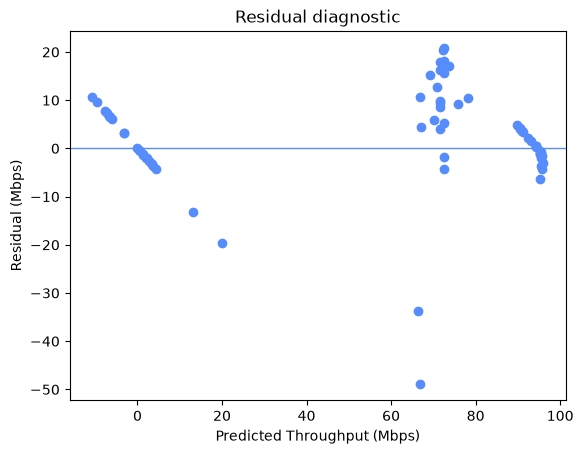

In [105]:
residual = true_target - pred_linear_regression

fig, ax = plt.subplots()
ax.scatter (pred_linear_regression, residual)#, alpha=0.55)
ax.axhline (0, linewidth=1)
ax.set_xlabel("Predicted Throughput (Mbps)")
ax.set_ylabel("Residual (Mbps)")
ax.set_title("Residual diagnostic")

plt.savefig("../media/06_04.png", dpi=300, bbox_inches='tight')
plt.show()

#### Ý nghĩa
- Mô hình Linear Regression thường có kết quả dự đoán lệch so với kết quả đúng khoảng 20 Mbps. Tuy nhiên, có khoảng 3 trường hợp mà giá trị mô hình dự đoán lớn hơn giá trị đúng từ hơn 20 đến 50 Mbps

### 5. Đường tham chiếu của giá trị đúng và dự đoán của mô hình Linear Regression

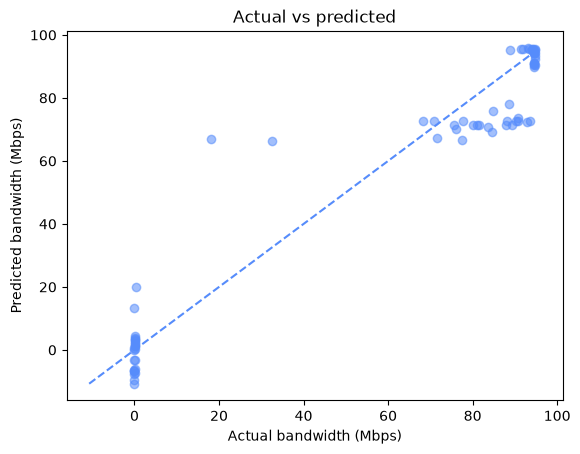

In [104]:
fig, ax = plt.subplots()
ax.scatter (true_target, pred_linear_regression, alpha=0.55)
low = min(true_target.min(), pred_linear_regression.min())
high = max(true_target.max(), pred_linear_regression.max())
ax.plot([low, high], [low, high], linestyle="--")
ax.set_xlabel("Actual bandwidth (Mbps)")
ax.set_ylabel("Predicted bandwidth (Mbps)")
ax.set_title("Actual vs predicted")

plt.savefig("../media/06_05.png", dpi=300, bbox_inches='tight')
plt.show()

#### Ý nghĩa
- Các giá trị của băng thông thực tế tập trung ở hai mức: gần 0 Mbps và từ 60 Mbps trở lên. Mô hình dự đoán tốt các giá trị băng thông ở hai khoảng này, nhưng lại có sai lệch nhiều với các giá trị băng thông trong khoảng từ 20 Mps đến 40 Mbps